# Using the Planck map as a dust model

I'm not happy with the Green+Zucker maps at high distances - this very quickly gets outside of their reliable distance range. So, what about using the Planck map?

## Imports

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from dustmaps.planck import fetch as fetch_planck, PlanckQuery
from dustmaps.bayestar import BayestarQuery
from dustmaps.decaps import DECaPSQueryLite
from astropy.coordinates import SkyCoord, galactocentric_frame_defaults
from astropy import units as u

In [2]:
# fetch_planck()

In [5]:
planck = PlanckQuery()
bayestar = BayestarQuery(max_samples=1)
decaps = DECaPSQueryLite(mean_only=True)

Loading pixel_info ...
Loading samples ...
Loading best_fit ...
Replacing NaNs in reliable distance estimates ...
Sorting pixel_info ...
Extracting hp_idx_sorted and data_idx at each nside ...
  nside = 64
  nside = 128
  nside = 256
  nside = 512
  nside = 1024
t = 14.850 s
  pix_info:   0.551 s
   samples:   2.664 s
      best:   2.273 s
       nan:   0.022 s
      sort:   9.236 s
       idx:   0.105 s
Loading meta pixel info...
Meta pixel info loaded!


## A first look at the Planck map

In [30]:
x_values = np.linspace(-180, 180, endpoint=False, num=200)
y_values = np.linspace(-90, 90, num=100)
x, y = [array.flatten() for array in np.meshgrid(x_values, y_values)]

coords = SkyCoord(l=x, b=y, unit="deg", frame="galactic")

reddening = planck.query(coords).reshape(y_values.size, x_values.size)


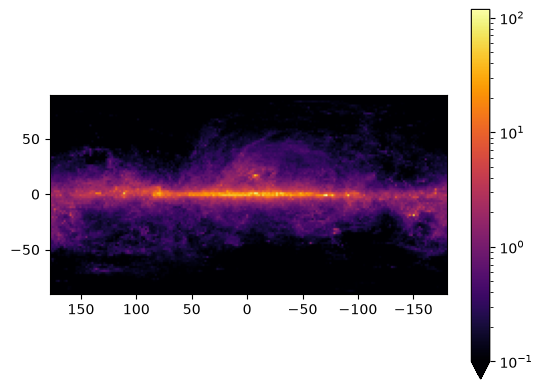

In [35]:
plt.imshow(
    reddening * 3.1,
    origin="lower",
    norm="log",
    cmap="inferno",
    vmin=0.1,
    extent=(x_values.min(), x_values.max(), y_values.min(), y_values.max()),
)
plt.gca().invert_xaxis()
plt.colorbar(extend="min")

Well shit, it goes up to A_V of ~100! This dust map doesn't fuck around.

## Projecting it into 3D

### First off: what is a max distance?

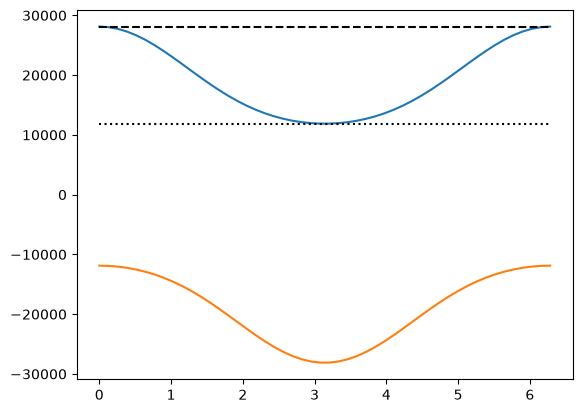

In [43]:
l = np.radians(np.linspace(0, 360))

r_sun = 8122
r_gal = 20000
r_sun_cos_l = r_sun * np.cos(l)
sqrt_part = np.sqrt(4*r_sun_cos_l**2 - 4*(r_sun**2 - r_gal**2))

d_max_upper = (2*r_sun_cos_l + sqrt_part) / 2
d_max_lower = (2*r_sun_cos_l - sqrt_part) / 2

plt.plot(l, d_max_upper)
plt.plot(l, d_max_lower)
plt.plot([0, 2*np.pi], [r_sun + r_gal]*2, 'k--')
plt.plot([0, 2*np.pi], [r_gal - r_sun]*2, 'k:')

Yay! That's a well-behaved function and I can just use the upper solution. Perfect.

### Some helpers

In [99]:
DEFAULT_R_SUN = galactocentric_frame_defaults.get()["galcen_distance"].to(u.pc).value


class PlanckQuery3D:
    def __init__(
        self,
        max_distance=20000,
        scale_length=3,
        r_sun=DEFAULT_R_SUN,
        r_v=3.1,
    ):
        # Todo reference to out of class object; remove in final code
        self._dust_map = planck
        self.max_distance = max_distance
        self.scale_length = scale_length
        self.r_sun = r_sun
        self.r_v = r_v

    def query(self, coords, mode="linear"):
        coords = coords.transform_to("galactic")
        l_degrees = coords.l.to(u.deg).value
        distance = coords.distance.to(u.pc).value

        max_distances = self._calculate_maximum_distance(l_degrees)
        distance_fractions = np.clip(distance / max_distances, 0, 1)
        total_extinctions = self.r_v * self._dust_map.query(coords)
        if mode == "linear":
            return distance_fractions * total_extinctions

    def _calculate_maximum_distance(self, l_degrees):
        r_sun_cos_l = 2 * self.r_sun * np.cos(np.radians(l_degrees))
        return (
            r_sun_cos_l
            + np.sqrt(r_sun_cos_l**2 - 4 * (self.r_sun**2 - self.max_distance**2))
        ) / 2


In [100]:
planck_3d = PlanckQuery3D()

### Try it out!

In [102]:
l_values = np.linspace(0, 360, endpoint=False, num=90)
distances = np.linspace(0, 20000, num=20)

l, d = [array.flatten() for array in np.meshgrid(l_values, distances)]
b = np.zeros(len(l))

coords = SkyCoord(l=l*u.deg, b=b*u.deg, distance=d*u.pc, frame="galactic")

In [110]:
planck_dust = planck_3d.query(coords)
bayestar_dust = 3.1 * bayestar.query(coords, mode="best")
decaps_dust = 3.1 * decaps.query(coords)

/home/emily/code/gaianir-open-clusters/.venv/lib/python3.13/site-packages/dustmaps/bayestar.py:432: RuntimeWarning: divide by zero encountered in log10
  dm = 5. * (np.log10(d) + 2.)
/home/emily/code/gaianir-open-clusters/.venv/lib/python3.13/site-packages/dustmaps/decaps.py:864: RuntimeWarning: divide by zero encountered in log10
  dm = 5. * (np.log10(d) + 2.)


[None, None]

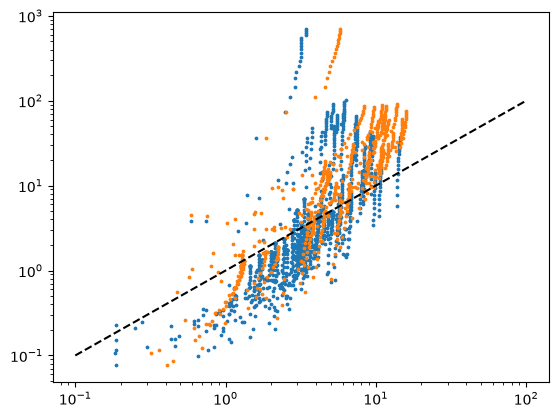

In [111]:
plt.scatter(bayestar_dust, planck_dust, s=3)
plt.scatter(decaps_dust, planck_dust, s=3)
plt.plot([0.1, 100], [0.1, 100], 'k--')
plt.gca().set(xscale="log", yscale="log")